# 00

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [2]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=3.5, res_width=0,
    test_every=-1
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_test_views()
len(train_views), len(test_views)

Read dataset in COLMAP format.


(279, 0)

In [3]:
# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=True,
    black_background=False,
)
voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03", 95000)
voxel_model.freeze_vox_geo()

morton_code_tensor = voxel_model.vox_morton_code.clone().detach()
vox_roots_tensor = voxel_model.vox_root.clone().detach()
vox_length_tensor = voxel_model.vox_size.clone().detach()
vox2corners_tensor = voxel_model.vox_key.clone().detach()
vox_params_geo_tensor = voxel_model.vox_conners_geo_params.clone().detach()
vox_params_color_tensor = voxel_model.vox_static_rgbs.clone().detach()

print(f"morton_code_tensor={morton_code_tensor.shape, morton_code_tensor.dtype}")
print(f"vox_roots_tensor={vox_roots_tensor.shape, vox_roots_tensor.dtype}")
print(f"vox_length_tensor={vox_length_tensor.shape, vox_length_tensor.dtype}")
print(f"vox2corners_tensor={vox2corners_tensor.shape, vox2corners_tensor.dtype}")
print(f"vox_params_geo_tensor={vox_params_geo_tensor.shape, vox_params_geo_tensor.dtype}")
print(f"vox_params_color_tensor={vox_params_color_tensor.shape, vox_params_color_tensor.dtype}")

morton_code_tensor=(torch.Size([9749024, 1]), torch.int64)
vox_roots_tensor=(torch.Size([9749024, 3]), torch.float32)
vox_length_tensor=(torch.Size([9749024, 1]), torch.float32)
vox2corners_tensor=(torch.Size([9749024, 8]), torch.int64)
vox_params_geo_tensor=(torch.Size([16611122, 1]), torch.float32)
vox_params_color_tensor=(torch.Size([9749024, 3]), torch.float32)


In [4]:
a_view = train_views[0]
ss = 1.0

w_src, h_src = a_view.render_width, a_view.render_height
w, h = round(w_src * ss), round(h_src * ss)
w_ss, h_ss = w / w_src, h / h_src

camera_settings = decompress_render.renderer.CameraSettings(
    image_width=w, 
    image_height=h, 
    tanfovx=a_view.tanfovx, 
    tanfovy=a_view.tanfovy, 
    cx=a_view.cx * w_ss,
    cy=a_view.cy * h_ss,
    w2c_matrix=a_view.world2view.cuda(),
    c2w_matrix=a_view.view2world.cuda()
)

render_settings = decompress_render.renderer.RenderSettings(
    num_sample_per_vox=3,
    bg_color=float(voxel_model.white_background),
    near=a_view.near,
    need_depth=True,
    track_max_w=False,
    debug=True,
)


N: 9749024 


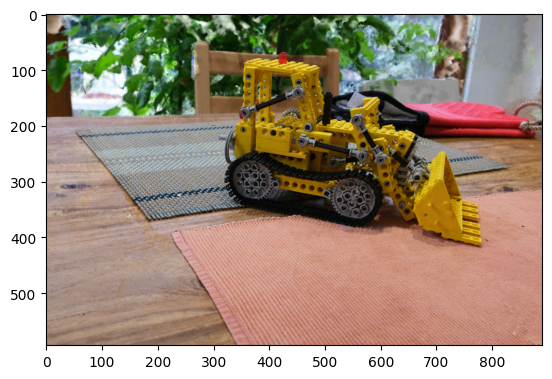

In [5]:
result_rendered = decompress_render.renderer.rasterize_voxels_main(
    camera_settings=camera_settings,
    render_settings=render_settings,
    morton_code=morton_code_tensor,
    vox_roots=vox_roots_tensor,
    vox_length=vox_length_tensor,
    vox2corners=vox2corners_tensor,
    vox_params_geo=vox_params_geo_tensor,
    vox_params_color=vox_params_color_tensor,
)

img_out = torch.permute(result_rendered[0].clamp(0, 1), dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(img_out)

# 01

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [ ]:
def get_polynomials_coefs_sqrtinv(max_degree):
    list_b = [1]
    temp = 1
    for n in range(1, max_degree+1):
        temp *= (2 * n - 1) / (2 * n)
        list_b.append(temp)

    return np.array(list_b, np.float32)


def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=0,
        ss=1.0,
        white_background=False,
        black_background=True,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    geometry_info["morton_code_tensor"] = voxel_model_frame.vox_morton_code.clone().detach()
    geometry_info["vox_roots_tensor"] = voxel_model_frame.vox_root.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame.vox_conners_geo_params.clone().detach()

    if load_attribute_field:
        geometry_info["vox_params_color_tensor"] = voxel_model_frame.vox_static_rgbs.clone().detach()

    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.5, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):

        w, h = view_info.render_width, view_info.render_height

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    
    @torch.compiler.disable
    def apply_subview_phiTphi_with_F(self, voxel_attribute, view_info):

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_transformed_attribute = decompress_render.renderer.geometry_attention_transform_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_attribute=voxel_attribute, # use as input voxel_attribute 
        )

        return out_transformed_attribute
    
    
    # @torch.compiler.disable
    def apply_full_phiTphi_with_F(self, voxel_attribute, scene_dataset):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        list_views = scene_dataset.get_encoder_views()
        transformed_attribute = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )
        # vi = 0
        for view in list_views:
            s = time.time()
            transformed_attribute = transformed_attribute + self.apply_subview_phiTphi_with_F(voxel_attribute, view)
            # print(f"++++ Apply_full_phiTphi_with_F: finished view {vi} in {time.time()-s}")
            # vi += 1

        return transformed_attribute

    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute, # use as input voxel_attribute 
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0))

        return rendered_image

    def apply_A_transpose(
            self,
            lowres_denfield,
            decoded_attribute_field,
            scene_dataset,
            optim_opt={}
        ):

        MSE_calculator = torch.nn.MSELoss()

        approx_attribute_field = torch.nn.Parameter(torch.full(
            [self.num_voxels, 3], 0.5, 
            dtype=torch.float32, device="cuda"
        ))
        optimizer = torch.optim.Adam([approx_attribute_field], lr=optim_opt.get("lr", 0.001))
        train_views = scene_dataset.get_train_views()

        i=0
        for loop in range(optim_opt.get("num_scene_loop", 30)):
            for view in train_views:
                ##
                optimizer.zero_grad()
                true_low_res_img   = lowres_denfield.apply_phi_with_F(decoded_attribute_field, view)
                approx_low_res_img = self.apply_phi_with_F(approx_attribute_field, view)
                ###
                mse_val = MSE_calculator(approx_low_res_img, true_low_res_img)
                mse_val.backward()
                ###
                if (i%100==0):
                    print(f"Apply_A_transpose: loop = {loop} iter = {i} psnr={-10 * np.log10(mse_val.detach().cpu())}")
                optimizer.step()
                i+=1

        output = approx_attribute_field.detach()
        
        # Cleaning
        optimizer.zero_grad()
        del optimizer
        torch.cuda.empty_cache()

        return output

    # @torch.compiler.disable
    def apply_scaled_rotation_phiTphi(self, voxel_attribute, scene_dataset, rotation_opt={}):
        output = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )

        diagonal = self.apply_full_phiTphi_with_F(
            torch.ones_like(voxel_attribute), 
            scene_dataset
        ).detach()

        sqrtinv_diagonal = torch.where(
            diagonal>0.0,
            1.0 / torch.sqrt(diagonal),
            1.0
        )
        # sqrtinv_diagonal = torch.ones_like(diagonal)

        max_degree = rotation_opt.get("max_degree", 10)
        poly_coefs_sqrtinv = get_polynomials_coefs_sqrtinv(max_degree)
        signal = voxel_attribute

        muy_phi = rotation_opt.get("muy_phi", 1.0)
        output = signal * poly_coefs_sqrtinv[0] * np.sqrt(2*muy_phi)
        temp_val = signal
        
        for p in range(1, max_degree):
            # s = time.time()
            Xb = self.apply_full_phiTphi_with_F(
                temp_val*sqrtinv_diagonal,
                scene_dataset
            ) * sqrtinv_diagonal

            temp_val = temp_val - 2 * muy_phi * Xb
            output = output + temp_val * poly_coefs_sqrtinv[p] * np.sqrt(2*muy_phi)
            # print(f"+++ Apply_scaled_rotation_phiTphi: finished degree {p} in {time.time() - s}")

        output = output * sqrtinv_diagonal
        return output
    
    def decoding_attribute_field(self, encoded_coefs, scene_dataset, rotation_opt={}):
        decoded_attribute_field = self.apply_scaled_rotation_phiTphi(
            encoded_coefs,
            scene_dataset,
            rotation_opt
        )
        return decoded_attribute_field

    def encoding_attribute_field(self, voxel_delta_attribute, scene_dataset, rotation_opt={}, encoding_opts={}):

        MSE_calculator = torch.nn.MSELoss()
        MSE_calculator2 = torch.nn.MSELoss()

        encoded_coefs = torch.nn.Parameter(torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        ))
        lambda_l1 = encoding_opts.get("lambda_l1", 0.0)
        optimizer = torch.optim.Adam([encoded_coefs], lr=encoding_opts.get("lr", 0.001))
        train_views = scene_dataset.get_train_views()

        i=0
        for loop in range(encoding_opts.get("num_loop", 30)):
            for view in train_views:
                # Refresh
                # if (i%encoding_opts.get("update_frequency", 10)) == 0:
                    # if i > 0:
                        # print(f"Encoding_attribute_field: updating at loop = {loop} iter = {i}")
                        # mse_val.backward()
                        # optimizer.step()
                    
                    ## Refresh
                    # print(f"Encoding_attribute_field: Refreshing at loop = {loop} iter = {i}")

                optimizer.zero_grad()
                mse_val = lambda_l1 * encoded_coefs.abs().sum()
                decoded_attribute_field = self.apply_scaled_rotation_phiTphi(
                    encoded_coefs,
                    scene_dataset,
                    rotation_opt
                )

                true_rendered_img_field   = self.apply_phi_with_F(voxel_delta_attribute, view).detach()
                approx_rendered_img_field = self.apply_phi_with_F(decoded_attribute_field, view).detach()

                ###
                mse_val_sub = MSE_calculator(true_rendered_img_field, approx_rendered_img_field).detach()
                mse_val_real = MSE_calculator2(voxel_delta_attribute, decoded_attribute_field)
                print(f"Encoding_attribute_field: loop = {loop} iter = {i} psnr={-10 * np.log10(mse_val_sub.detach().cpu())} psnr_delta_field={-10 * np.log10(mse_val_real.detach().cpu())}")
                mse_val = mse_val + mse_val_real

                ###
                mse_val.backward()
                optimizer.step()

                ###
                i+=1

        output = encoded_coefs.detach()
        
        # Cleaning
        optimizer.zero_grad()
        del optimizer
        torch.cuda.empty_cache()

        return output

class MultiScaleSplatsEncoder:
    def __init__(
        self,
        scene_dataset_source_path,
        list_density_field_paths,
        num_sample_per_voxel=1,
        scene_loader_opt={
            "res_downscale": 3.5,
            "res_width": 0,
            "encoder_view_every": 1,
        },
        A_transpose_opt={
            "lr": 0.001,
            "num_scene_loop": 20,
        },
        rotation_opt={
            "max_degree":10,
            "muy_phi": 1.0,
        },
        encoding_opts={
            "lr": 0.001,
            "lambda_l1": 0.0,
            "num_loop": 30,
            "update_frequency": 10
        }
    ):
        
        self.list_density_field = []
        for path in list_density_field_paths:
            self.list_density_field.append(
                DensityField(path, num_sample_per_voxel, load_attribute_field=True)
            )

        self.scene_dataset = Scene(
            scene_dataset_source_path, image_dir_name="images",
            res_downscale=scene_loader_opt["res_downscale"],
            res_width=scene_loader_opt["res_width"],
            encoder_view_every=scene_loader_opt["encoder_view_every"],
        )

        self.A_transpose_opt=A_transpose_opt
        self.rotation_opt=rotation_opt
        self.encoding_opts=encoding_opts

    def testing_encoding(self):
        list_quantized_coefs = []
        L = len(self.list_density_field)
        decoded_attribute_field = self.list_density_field[0].voxel_attribute_field

        for i in range(1, L, 1):
            print(f"Encoding level={i}")
            lowres_denfield = self.list_density_field[i-1]
            highres_denfield = self.list_density_field[i]

            # A^T
            approx_attribute_field = highres_denfield.apply_A_transpose(
                lowres_denfield,
                decoded_attribute_field,
                self.scene_dataset,
                optim_opt=self.A_transpose_opt
            )

            # Encoding residual gap 
            residual_gap_true = highres_denfield.voxel_attribute_field - approx_attribute_field
            encoded_coefs = highres_denfield.encoding_attribute_field(
                residual_gap_true,
                self.scene_dataset,
                rotation_opt=self.rotation_opt,
                encoding_opts=self.encoding_opts,
            )

            # Quantizer
            quantized_coefs = encoded_coefs # Testing with no quantization
            list_quantized_coefs.append(
                quantized_coefs
            )

            #Decoding Residual Gap
            residual_gap_decoded = highres_denfield.decoding_attribute_field(
                quantized_coefs,
                self.scene_dataset,
                rotation_opt=self.rotation_opt
            )
            decoded_attribute_field = approx_attribute_field + residual_gap_decoded

        return decoded_attribute_field

In [ ]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=3.5, res_width=0,
    encoder_view_every=20
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
len(train_views), len(test_views)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 18 encoding views


(279, 18)

In [7]:
den_field = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter071999_model.pt")

temp = den_field.apply_scaled_rotation_phiTphi(den_field.voxel_attribute_field, scene_dataset, rotation_opt={"max_degree":20})

+++ Apply_scaled_rotation_phiTphi: finished degree 1 in 0.31197571754455566
+++ Apply_scaled_rotation_phiTphi: finished degree 2 in 0.30341553688049316
+++ Apply_scaled_rotation_phiTphi: finished degree 3 in -1.8813834190368652
+++ Apply_scaled_rotation_phiTphi: finished degree 4 in 0.2979860305786133
+++ Apply_scaled_rotation_phiTphi: finished degree 5 in 0.29437971115112305
+++ Apply_scaled_rotation_phiTphi: finished degree 6 in 0.29578208923339844
+++ Apply_scaled_rotation_phiTphi: finished degree 7 in 0.29060816764831543
+++ Apply_scaled_rotation_phiTphi: finished degree 8 in 0.28951311111450195
+++ Apply_scaled_rotation_phiTphi: finished degree 9 in 0.28987741470336914
+++ Apply_scaled_rotation_phiTphi: finished degree 10 in 0.2839837074279785
+++ Apply_scaled_rotation_phiTphi: finished degree 11 in 0.28490734100341797
+++ Apply_scaled_rotation_phiTphi: finished degree 12 in 0.2850685119628906
+++ Apply_scaled_rotation_phiTphi: finished degree 13 in 0.2813720703125
+++ Apply_scale

In [5]:

den_field = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter071999_model.pt")

encoded_coefs = torch.nn.Parameter(torch.full(
    [den_field.num_voxels, 3], 0.0, 
    dtype=torch.float32, device="cuda"
))

temp = den_field.apply_scaled_rotation_phiTphi(encoded_coefs, scene_dataset, rotation_opt={"max_degree":5})

+++ Apply_scaled_rotation_phiTphi: finished degree 1 in 0.4690432548522949
+++ Apply_scaled_rotation_phiTphi: finished degree 2 in 0.5574979782104492
+++ Apply_scaled_rotation_phiTphi: finished degree 3 in 0.49880409240722656
+++ Apply_scaled_rotation_phiTphi: finished degree 4 in 0.5021035671234131


In [3]:
torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter063999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter071999_model.pt",
    ],
    num_sample_per_voxel=1,
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 23
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 20,
    },
    rotation_opt={
        "max_degree": 5,
        "muy_phi": 1.0,
    },
    encoding_opts={
        "lr": 0.005,
        "lambda_l1": 0.0,
        "num_loop": 20,
        "update_frequency": None
    }
)

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 13 encoding views


In [ ]:
encoder.testing_encoding()

Encoding level=1
Apply_A_transpose: loop = 0 iter = 0 psnr=12.677923202514648
Apply_A_transpose: loop = 0 iter = 1 psnr=12.591008186340332
Apply_A_transpose: loop = 0 iter = 2 psnr=12.497760772705078
Apply_A_transpose: loop = 0 iter = 3 psnr=12.579684257507324
Apply_A_transpose: loop = 0 iter = 4 psnr=12.57172679901123
Apply_A_transpose: loop = 0 iter = 5 psnr=12.59124755859375
Apply_A_transpose: loop = 0 iter = 6 psnr=12.489547729492188
Apply_A_transpose: loop = 0 iter = 7 psnr=12.496657371520996
Apply_A_transpose: loop = 0 iter = 8 psnr=12.461791038513184
Apply_A_transpose: loop = 0 iter = 9 psnr=12.557878494262695
Apply_A_transpose: loop = 0 iter = 10 psnr=12.528427124023438
Apply_A_transpose: loop = 0 iter = 11 psnr=12.603397369384766
Apply_A_transpose: loop = 0 iter = 12 psnr=12.652772903442383
Apply_A_transpose: loop = 0 iter = 13 psnr=12.784317016601562
Apply_A_transpose: loop = 0 iter = 14 psnr=12.871868133544922
Apply_A_transpose: loop = 0 iter = 15 psnr=12.937433242797852
App

In [8]:
scene_dataset

In [11]:
high_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter045999_model.pt")
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter013999_model.pt")

approx_attribute_field = high_res.apply_A_transpose(
    low_res,
    low_res.voxel_attribute_field,
    scene_dataset,
    optim_opt={
        "lr": 0.001,
        "num_scene_loop": 20
    }
)


Apply_A_transpose: loop = 0 iter = 0 psnr=13.129070281982422
Apply_A_transpose: loop = 0 iter = 1 psnr=13.043161392211914
Apply_A_transpose: loop = 0 iter = 2 psnr=12.98178482055664
Apply_A_transpose: loop = 0 iter = 3 psnr=13.056324005126953
Apply_A_transpose: loop = 0 iter = 4 psnr=13.036216735839844
Apply_A_transpose: loop = 0 iter = 5 psnr=13.06039047241211
Apply_A_transpose: loop = 0 iter = 6 psnr=12.966121673583984
Apply_A_transpose: loop = 0 iter = 7 psnr=12.958433151245117
Apply_A_transpose: loop = 0 iter = 8 psnr=12.908068656921387
Apply_A_transpose: loop = 0 iter = 9 psnr=12.973770141601562
Apply_A_transpose: loop = 0 iter = 10 psnr=12.945021629333496
Apply_A_transpose: loop = 0 iter = 11 psnr=13.015901565551758
Apply_A_transpose: loop = 0 iter = 12 psnr=13.08083438873291
Apply_A_transpose: loop = 0 iter = 13 psnr=13.22327709197998
Apply_A_transpose: loop = 0 iter = 14 psnr=13.326269149780273
Apply_A_transpose: loop = 0 iter = 15 psnr=13.392793655395508
Apply_A_transpose: loo

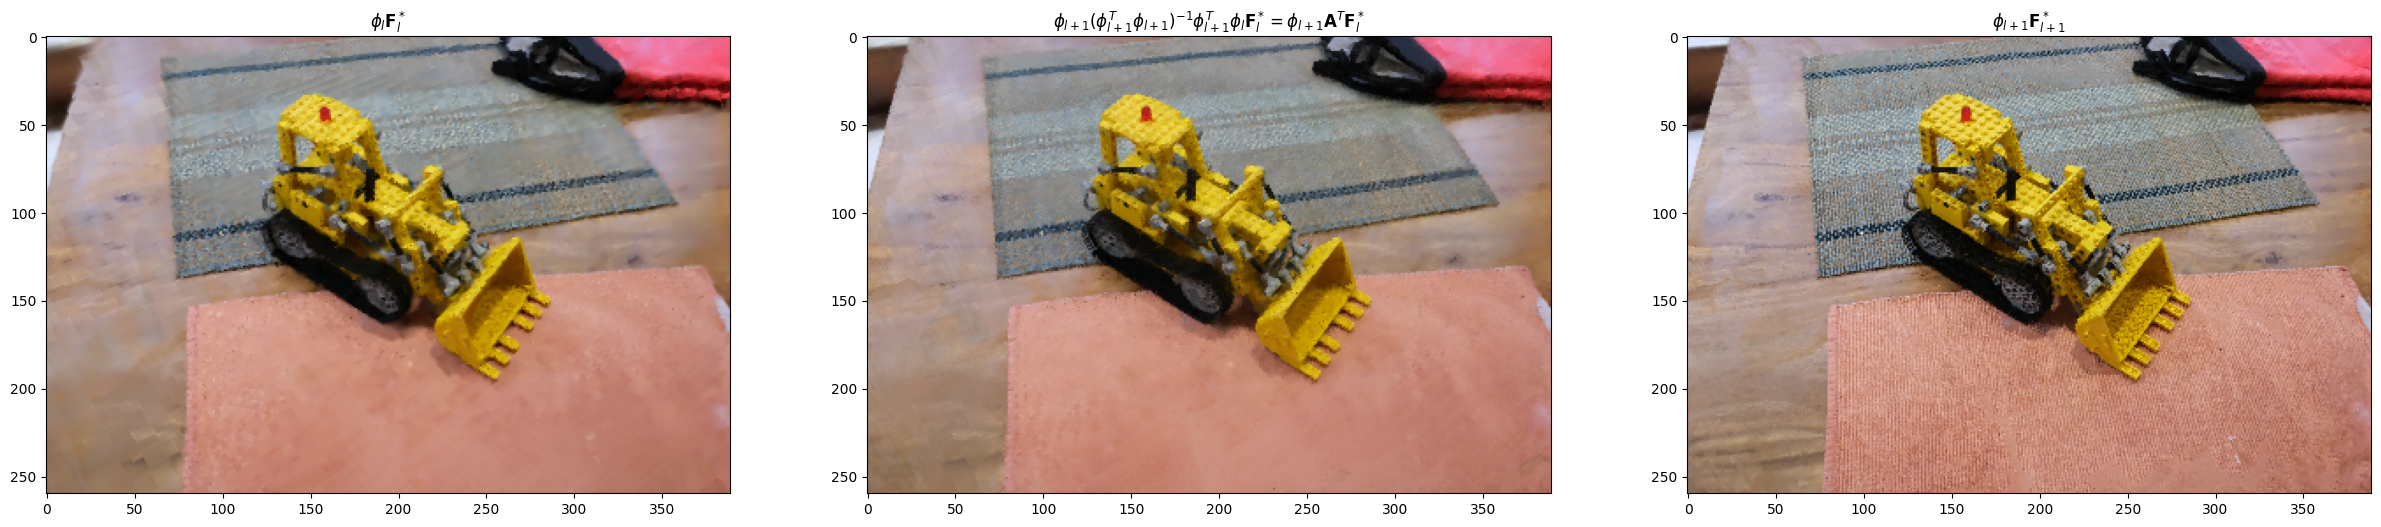

In [12]:
rendered_img_low = low_res.apply_phi(train_views[50]).cpu().numpy()
rendered_img_high = high_res.apply_phi(train_views[50]).cpu().numpy()
rendered_img_low_approx = high_res.apply_phi_with_F(approx_attribute_field, train_views[50]).detach().cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[0].set_title(r"$\phi_l \mathbf{F}_l^*$")
ax[1].imshow(rendered_img_low_approx)
ax[1].set_title(r"$\phi_{l+1} (\phi_{l+1}^T\phi_{l+1})^{-1} \phi_{l+1}^T\phi_l \mathbf{F}_l^* = \phi_{l+1} \mathbf{A}^T \mathbf{F}_l^*$")
ax[2].imshow(rendered_img_high)
ax[2].set_title(r"$\phi_{l+1} \mathbf{F}_{l+1}^*$")

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()

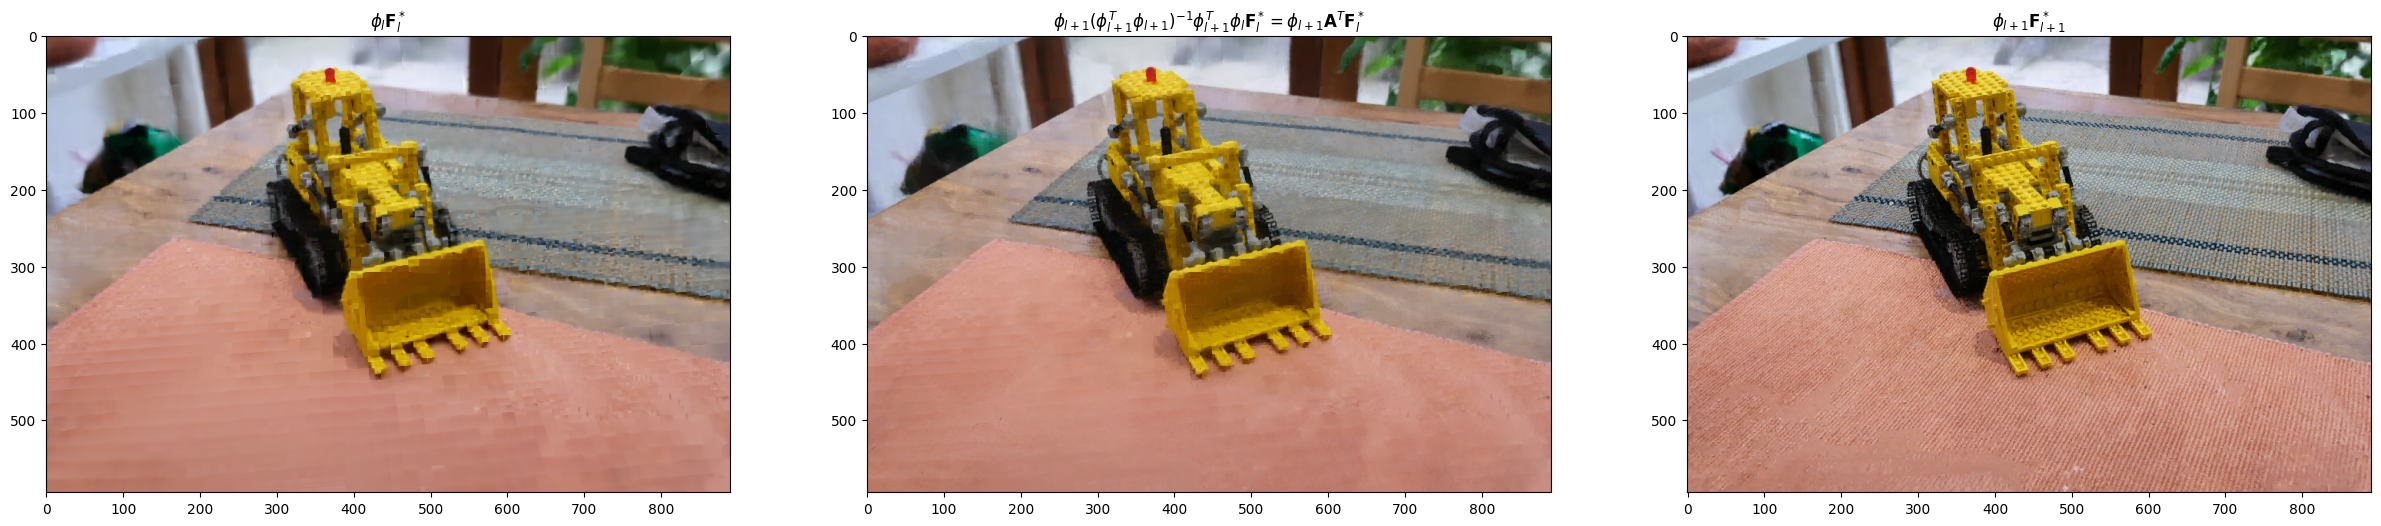

In [7]:
rendered_img_low = low_res.apply_phi(train_views[10]).cpu().numpy()
rendered_img_high = high_res.apply_phi(train_views[10]).cpu().numpy()
rendered_img_low_approx = high_res.apply_phi_with_F(approx_attribute_field, train_views[10]).detach().cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[0].set_title(r"$\phi_l \mathbf{F}_l^*$")
ax[1].imshow(rendered_img_low_approx)
ax[1].set_title(r"$\phi_{l+1} (\phi_{l+1}^T\phi_{l+1})^{-1} \phi_{l+1}^T\phi_l \mathbf{F}_l^* = \phi_{l+1} \mathbf{A}^T \mathbf{F}_l^*$")
ax[2].imshow(rendered_img_high)
ax[2].set_title(r"$\phi_{l+1} \mathbf{F}_{l+1}^*$")

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()

In [8]:
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter013999_model.pt")

temp_list = []

for i in range(100):
    attribute = torch.zeros_like(low_res.voxel_attribute_field)
    attribute[i, 0]=1
    transformed_attribute = torch.zeros_like(low_res.voxel_attribute_field)
    for view in train_views:
        transformed_attribute = transformed_attribute + low_res.apply_subview_phiTphi_with_F(attribute, view).detach()

    temp_list.append(transformed_attribute[:100, 0])
    if i%10==0:
        print(f"Done {i}")


Done 0
Done 10
Done 20
Done 30
Done 40
Done 50
Done 60
Done 70
Done 80
Done 90


In [9]:
temp_m = torch.stack(temp_list, axis=1)


In [10]:
temp_m.shape

torch.Size([100, 100])

In [13]:
temp_m[:20, :20].cpu().numpy()

array([[2.508e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 4.886e-08, 0.000e+00, 0.000e+00, 2.696e-07, 9.237e-06, 4.003e-04, 1.918e-04, 7.531e-03, 2.832e-04, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 7.664e-05, 2.869e-04, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 2.869e-04, 7.310e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 4.441e-06],
       [0.000e+00, 0.000e+00, 0.000e+00, 6.319e-01, 2.010e-01, 3.226e-02, 0.000e+00, 1.418e-06, 4.140e-07, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, 2.010e-01, 1.344e-01, 1.136e-02, 1.588e-03,

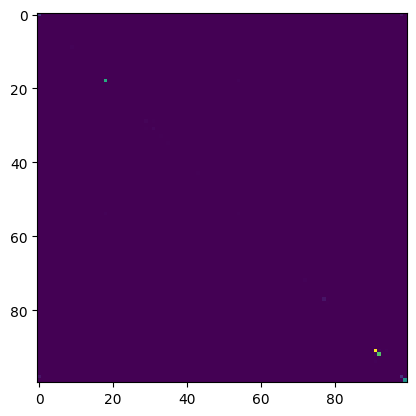

In [14]:
plt.imshow(temp_m[:100, :100].cpu().numpy())

In [15]:
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter013999_model.pt")

temp_list = []

attribute =  torch.nn.Parameter(torch.full(
    [low_res.num_voxels, 3], 1.0, 
    dtype=torch.float32, device="cuda"
))


transformed_attribute = torch.zeros_like(low_res.voxel_attribute_field)
for view in train_views:
    transformed_attribute = transformed_attribute + low_res.apply_subview_phiTphi_with_F(attribute, view)




In [16]:
transformed_attribute.sum().backward()

In [17]:
attribute.grad.min(), attribute.grad.max(), attribute.grad

(tensor(0., device='cuda:0'),
 tensor(28865.0762, device='cuda:0'),
 tensor([[1.1978e+03, 1.1978e+03, 1.1978e+03],
         [2.9219e-02, 2.9219e-02, 2.9219e-02],
         [2.0830e+00, 2.0830e+00, 2.0830e+00],
         ...,
         [2.4619e+00, 2.4619e+00, 2.4619e+00],
         [1.7301e+02, 1.7301e+02, 1.7301e+02],
         [1.8904e+01, 1.8904e+01, 1.8904e+01]], device='cuda:0'))

(array([5.599e+04, 7.933e+03, 2.058e+03, 9.210e+02, 4.030e+02, 1.360e+02, 4.000e+01, 2.700e+01, 1.400e+01, 9.000e+00]),
 array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000., 14000., 16000., 18000., 20000.]),
 <BarContainer object of 10 artists>)

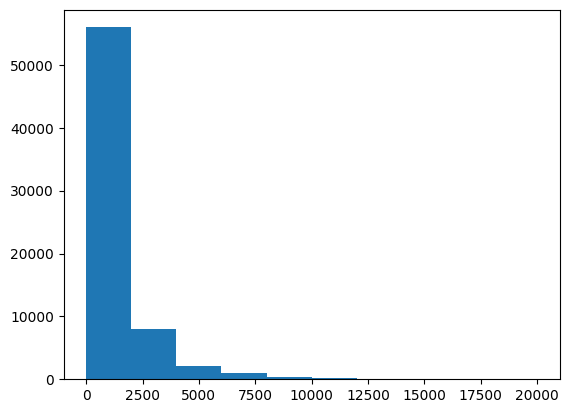

In [20]:
plt.hist(transformed_attribute[:, 0].detach().cpu().numpy(), range=(0, 20000))

(array([5.599e+04, 7.933e+03, 2.058e+03, 9.210e+02, 4.030e+02, 1.360e+02, 4.000e+01, 2.700e+01, 1.400e+01, 9.000e+00]),
 array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000., 14000., 16000., 18000., 20000.]),
 <BarContainer object of 10 artists>)

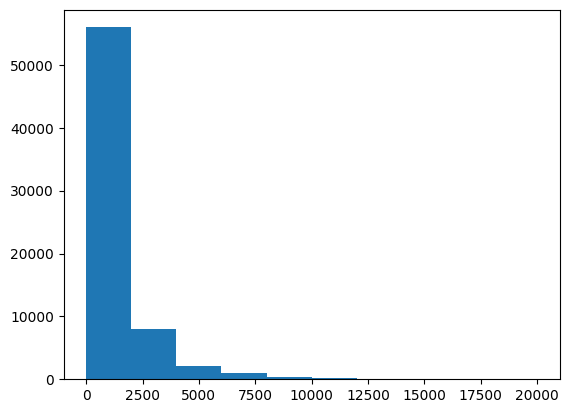

In [21]:
plt.hist(attribute.grad[:, 0].cpu().numpy(), range=(0, 20000))

In [ ]:
den_field = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter083999_model.pt")

voxel_attribute = den_field.voxel_attribute_field

temp = low_res.apply_scaled_rotation_phiTphi(voxel_attribute, scene_dataset, rotation_opt={})

* finished degree 1 in 0.8063819408416748
* finished degree 2 in 0.8185019493103027
* finished degree 3 in 0.8246159553527832
* finished degree 4 in 0.7909941673278809
* finished degree 5 in 0.8031153678894043
* finished degree 6 in 0.8123459815979004
* finished degree 7 in 0.811481237411499
* finished degree 8 in 0.8098764419555664
* finished degree 9 in 0.8011291027069092


In [27]:
temp

tensor([[-3.2885e-03,  2.6090e-03, -5.8527e-03],
        [ 9.6411e+00,  5.8185e+00,  2.7202e-01],
        [ 1.6941e+00,  1.6944e+00,  1.7483e+00],
        ...,
        [-1.2459e-02, -3.5884e-02, -4.6789e-02],
        [-1.0276e-02,  5.8676e-03, -1.2235e-02],
        [-1.4353e-03,  3.1231e-02, -2.5795e-03]], device='cuda:0')

In [22]:
torch.cuda.empty_cache()

In [12]:
np.set_printoptions(
    precision=3,        # Number of digits of precision for floating point output
    suppress=False,      # Suppress scientific notation
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)